In [1]:
import xarray as xr
import numpy as np
import cftime
import cmocean as cm
import matplotlib.pyplot as plt
import regionmask
from xmip.regionmask import merged_mask
import cartopy.crs as ccrs
import os
import pandas as pd
from pandas import Timestamp
# from xarrayutils.plotting import linear_piecewise_scale


In [2]:
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp no warming
# Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # all no warming

Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce30x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #temp warming 1 w/m2
Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce30x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #all warming 1 w/m2

# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce7_5x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #temp warming .5 w/m2
# Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce15x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #all warming .5 w/m2

warming = False
if warming:
    suffix = "_warming"
else:
    suffix = ""

In [3]:
def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})


    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})

    return ds_out

levels = 19
emulation_stability=True
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data/", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data 
if smooth:
    window = 10
    with ProgressBar():
        ds_input['uo'] = ds_input.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
        ds_input['vo'] = ds_input.vo.rolling(time=window, min_periods=1, center=False).mean().compute()


# our groundtruth is always just a time slice of the training (training is a bad name

if emulation_stability:
    repeats = 100
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 7303))

else:
    ds_groundtruth = ds_input.isel(time=slice(2903, 3503)).isel(lev=slice(None, levels))

ls_all = ['uo', 'vo', 'thetao', 'so', 'zos'] #['uo', 'vo', 'thetao', 'so', 'zos'], ['thetao', 'so', 'zos']
ls_temp = ['thetao', 'so', 'zos']
output_folder_all = Pred_path_all.split("/")[-2].split("_Train")[0]
output_path_all = os.path.join("./temp", output_folder_all)
output_folder_temp = Pred_path_all.split("/")[-2].split("_Train")[0]
output_path_temp = os.path.join("./temp", output_folder_temp)

if os.path.isdir(output_path_all):
    print("Using Output Folder : ", output_path_all)
else:
    print("Using Output Folder : ../outputs")
    output_path_all = "../outputs"

if os.path.isdir(output_path_temp):
    print("Using Output Folder : ", output_path_temp)
else:
    print("Using Output Folder : ../outputs")
    output_path_temp = "../outputs"

ds_prediction_raw_all = xr.open_zarr(Pred_path_all)

ds_prediction_raw_temp = xr.open_zarr(Pred_path_temp)
# if emulation_stability:
#     ds_groundtruth = ds_groundtruth.isel(time=slice(0, ds_prediction_all_raw.time.size))

# ds_prediction_all = post_processor(
#     ds_prediction_raw_all, ds_groundtruth, ls_all
# )
ds_prediction_all = post_processor(
    ds_prediction_raw_all, ds_groundtruth.isel(time = slice(0,ds_prediction_raw_all.time.size)), ls_all
)

ds_prediction_temp = post_processor(
    ds_prediction_raw_temp, ds_groundtruth.isel(time = slice(0,ds_prediction_raw_temp.time.size)), ls_temp
)


# Run the test to make sure the output is formatted correctly
ds_prediction_all = ds_prediction_all.transpose('time','lev',...)
ds_prediction_temp = ds_prediction_temp.transpose('time','lev',...)

Using Output Folder : ../outputs
Using Output Folder : ../outputs


In [4]:
ds_prediction_temp = ds_prediction_temp.transpose('time','lev',...)
ds_prediction_all = ds_prediction_all.transpose('time','lev',...)

In [5]:
ds_prediction_all['y']  = ds_prediction_all.y.assign_attrs(long_name='latitude')
ds_prediction_all['x']  = ds_prediction_all.x.assign_attrs(long_name='longitude')
ds_prediction_all['thetao'] = ds_prediction_all['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")

ds_prediction_temp['y']  = ds_prediction_temp.y.assign_attrs(long_name='latitude')
ds_prediction_temp['x']  = ds_prediction_temp.x.assign_attrs(long_name='longitude')
ds_prediction_temp['thetao'] = ds_prediction_temp['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")

In [ ]:
# Compute Basin Heat Content Time Series
Days_to_Eq = 1000

basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

mask = merged_mask(basins,ds_prediction_all.drop_vars(['lat','lon']))

atlantic_mask = xr.where(np.logical_or(mask == 0,mask == 1),1.0,np.nan)
pacific_mask = xr.where(np.logical_or(mask == 2,mask == 3),1.0,np.nan)
southern_ocean_mask = xr.where(mask == 7,1.0,np.nan)
indian_ocean_mask = xr.where(mask == 5,1.0,np.nan)

masks = atlantic_mask.to_dataset(name='Atlantic')
masks['Pacific']  = pacific_mask
masks['Southern'] = southern_ocean_mask
masks['Indian'] = indian_ocean_mask

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
ax_flat = ax.flatten()

for i, var in enumerate(list(masks.keys())):
    OHC_pred = ((ds_prediction_all['thetao']*c_p*rho_0*masks[var])*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev'])    
    OHC_pred.plot(ax = ax_flat[i], label = 'Slow + Fast', c = 'r')

    OHC_pred_temp = ((ds_prediction_temp['thetao']*c_p*rho_0*masks[var])*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev'])    
    OHC_pred_temp.plot(ax = ax_flat[i], label = 'Slow', c = 'b')
    
    ax_flat[i].legend()
    ax_flat[i].set_title("Heat Content " + var + " Ocean")
    coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[Days_to_Eq:].size), OHC_pred[Days_to_Eq:], 1)
    ax_flat[i].plot(OHC_pred[Days_to_Eq:].time.data, np.arange(OHC_pred[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'r', ls = '--')
    
    coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_temp[Days_to_Eq:].size), OHC_pred_temp[Days_to_Eq:], 1)
    ax_flat[i].plot(OHC_pred_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = 'b', ls = '--')

# plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Basins_OHC_Salinity_Long.png", bbox_inches='tight')


/state/partition1/job-50935139/ipykernel_1560199/639054358.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)
/state/partition1/job-50935139/ipykernel_1560199/639054358.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)
/state/partition1/job-50935139/ipykernel_1560199/639054358.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)


OHC portion of upper trend: 0.02
OHC portion of mid trend: 0.50
OHC portion of deep trend: 0.47
OHC portion of upper trend temp: 0.92
OHC portion of mid trend temp: 0.02
OHC portion of deep trend temp: 0.05


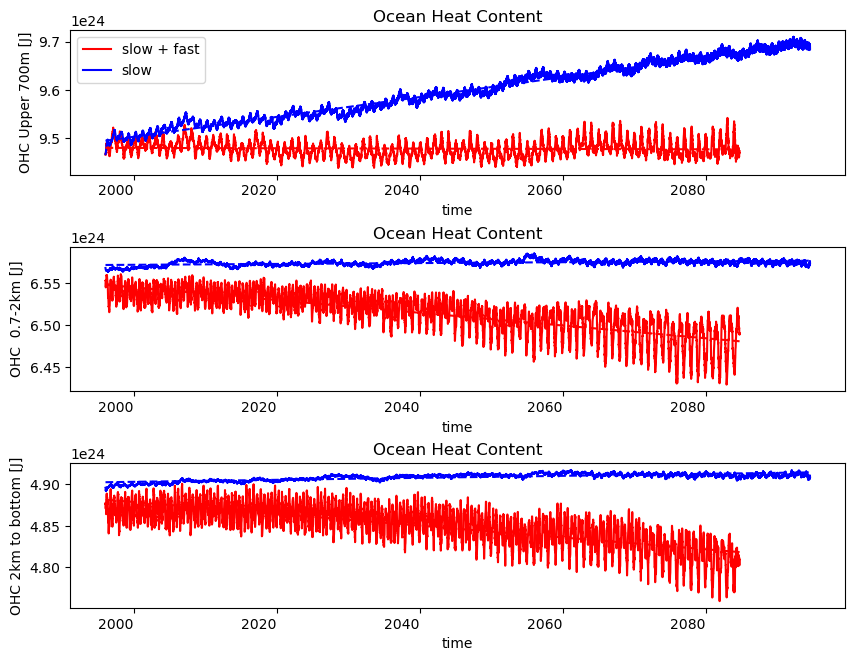

In [7]:
# Compute Basin Heat Content Time Series

Days_to_Eq = 0
c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(3,1,figsize=(10,7.5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred_upper = ((ds_prediction_all['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()    
OHC_pred_upper = OHC_pred_upper.rename('OHC Upper 700m')
OHC_pred_upper = OHC_pred_upper.assign_attrs(units = 'J')

OHC_pred_upper.plot(ax = ax[0], label = 'slow + fast', c = 'r')

OHC_pred_upper_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute() 
OHC_pred_upper_temp = OHC_pred_upper_temp.rename('OHC Upper 700m')
OHC_pred_upper_temp = OHC_pred_upper_temp.assign_attrs(units = 'J')

OHC_pred_upper_temp.plot(ax = ax[0], label = 'slow', c = 'b')

# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_upper[Days_to_Eq:].size), OHC_pred_upper[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper[Days_to_Eq:].time.data, np.arange(OHC_pred_upper[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'r', ls = '--')
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_upper_temp[Days_to_Eq:].size), OHC_pred_upper_temp[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = 'b', ls = '--')
ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)
ax[0].legend()

upper_trend = coeffs_OHC_pred_trend[0]*73
upper_trend_temp = coeffs_OHC_pred_trend_temp[0]*73


OHC_pred_mid = ((ds_prediction_all['thetao'].sel(lev = slice(700,2000))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
OHC_pred_mid = OHC_pred_mid.rename('OHC  0.7-2km')
OHC_pred_mid = OHC_pred_mid.assign_attrs(units = 'J')

OHC_pred_mid.plot(ax = ax[1], label = 'slow + fast', c = 'r')

OHC_pred_mid_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(700,2000))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()    
OHC_pred_mid_temp = OHC_pred_mid_temp.rename('OHC  0.7-2km')
OHC_pred_mid_temp = OHC_pred_mid_temp.assign_attrs(units = 'J')

OHC_pred_mid_temp.plot(ax = ax[1], label = 'slow', c = 'b')

ax[1].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_mid[Days_to_Eq:].size), OHC_pred_mid[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid[Days_to_Eq:].time.data, np.arange(OHC_pred_mid[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'r', ls = '--')
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_mid_temp[Days_to_Eq:].size), OHC_pred_mid_temp[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = 'b', ls = '--')
ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)

mid_trend = coeffs_OHC_pred_trend[0]*73
mid_trend_temp = coeffs_OHC_pred_trend_temp[0]*73


OHC_pred_deep = ((ds_prediction_all['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep = OHC_pred_deep.rename('OHC 2km to bottom')
OHC_pred_deep = OHC_pred_deep.assign_attrs(units = 'J')

OHC_pred_deep.plot(ax = ax[2], label = 'slow + fast', c = 'r')

OHC_pred_deep_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep_temp = OHC_pred_deep_temp.rename('OHC 2km to bottom')
OHC_pred_deep_temp = OHC_pred_deep_temp.assign_attrs(units = 'J')

OHC_pred_deep_temp.plot(ax = ax[2], label = 'slow', c = 'b')

# ax[0].legend()
ax[2].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_deep[Days_to_Eq:].size), OHC_pred_deep[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep[Days_to_Eq:].time.data, np.arange(OHC_pred_deep[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'r', ls = '--')
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_deep_temp[Days_to_Eq:].size), OHC_pred_deep_temp[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = 'b', ls = '--')
ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)

deep_trend = coeffs_OHC_pred_trend[0]*73
deep_trend_temp = coeffs_OHC_pred_trend_temp[0]*73

total_trend = upper_trend + mid_trend + deep_trend
total_trend_temp = upper_trend_temp + mid_trend_temp + deep_trend_temp

print(f'OHC portion of upper trend: {upper_trend/total_trend:.2f}')
print(f'OHC portion of mid trend: {mid_trend/total_trend:.2f}')
print(f'OHC portion of deep trend: {deep_trend/total_trend:.2f}')
print(f'OHC portion of upper trend temp: {upper_trend_temp/total_trend_temp:.2f}')
print(f'OHC portion of mid trend temp: {mid_trend_temp/total_trend_temp:.2f}')
print(f'OHC portion of deep trend temp: {deep_trend_temp/total_trend_temp:.2f}')

plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Depth_OHC_Long_"+suffix+".png", bbox_inches='tight')


In [ ]:
Days_to_Eq = 0

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,1,figsize=(10,5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred = ((ds_prediction_all['thetao'][Days_to_Eq:]*c_p*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
OHC_pred = OHC_pred.rename('Ocean Heat Content')
OHC_pred = OHC_pred.assign_attrs(units = 'J')

OHC_pred.plot(ax = ax[0], label = 'Slow + Fast', c = 'r')

OHC_pred_temp = ((ds_prediction_temp['thetao'][Days_to_Eq:]*c_p*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
OHC_pred_temp = OHC_pred_temp.rename('Ocean Heat Content')
OHC_pred_temp = OHC_pred_temp.assign_attrs(units = 'J')

OHC_pred_temp.plot(ax = ax[0], label = 'Slow', c = 'b')

# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[:].size), OHC_pred[:], 1)
ax[0].plot(OHC_pred[:].time.data, np.arange(OHC_pred[:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'r', ls = '--')
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_temp[:].size), OHC_pred_temp[:], 1)
ax[0].plot(OHC_pred_temp[:].time.data, np.arange(OHC_pred_temp[:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = 'b', ls = '--')
ax[0].legend(loc = 'lower right')

salinity = ((ds_prediction_all['so'][Days_to_Eq:]*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
salinity = salinity.rename('Salinity')
salinity = salinity.assign_attrs(units = 'g')

salinity.plot(ax = ax[1], label = 'slow + fast', c = 'r')

salinity_temp = ((ds_prediction_temp['so'][Days_to_Eq:]*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
salinity_temp = salinity_temp.rename('Salinity')
salinity_temp_temp = salinity_temp.assign_attrs(units = 'g')

salinity_temp.plot(ax = ax[1], label = 'slow', c = 'b')

# ax[1].legend()
ax[1].set_title("Ocean Total Salinity")
coeffs_salinity_trend= np.polyfit(np.arange(salinity[:].size), salinity[:], 1)
ax[1].plot(salinity[:].time.data, np.arange(salinity[:].size)*coeffs_salinity_trend[0] + coeffs_salinity_trend[1],c = 'r', ls = '--')

coeffs_salinity_trend_temp= np.polyfit(np.arange(salinity_temp[:].size), salinity_temp[:], 1)
ax[1].plot(salinity_temp[:].time.data, np.arange(salinity_temp[:].size)*coeffs_salinity_trend_temp[0] + coeffs_salinity_trend_temp[1],c = 'b', ls = '--')

print(coeffs_OHC_pred_trend[0]*73/1e21)

print(coeffs_salinity_trend[0]*73/1e17)

print(coeffs_OHC_pred_trend_temp[0]*73/1e21)

print(coeffs_salinity_trend_temp[0]*73/1e17)
plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/OHC_Salinity_Long"+suffix+".png", bbox_inches='tight')



In [ ]:
hfs_true = xr.open_zarr("/pscratch/sd/s/suryad/data/OM4_5daily_v0.2.1.zarr").drop_vars(['lon','lat'])['hfds']
hfs_true = hfs_true.sel(time = slice('1990-01-01','1999-12-31')).transpose('time',...)
hfs_true =  xr.concat([hfs_true] * repeats, dim="time")

In [24]:
def NinoIndexComputeClim(T,area,dt = 5, window = 150):
    T = T.load()
    T_clim = T.copy()
    T_clim = T_clim.sel(x = slice(118,260), y = slice(-5,5)).load()
    area = area.sel(x = slice(118,260), y = slice(-5,5))
    clim = T_clim.groupby('time.dayofyear').mean('time').compute()
    window = int(window/dt)
    print(window)
    for i, t in enumerate(T_clim.time.values):
        day = int(Timestamp(t).dayofyear)
        T_clim[i] = (T[i]-clim.sel(dayofyear=day)).data        

    T_clim = T_clim.rolling(time = window).mean()
    T_clim = (T_clim*area).sum(["x","y"])/area.sum(["x","y"])

    return T_clim[window:]

In [ ]:
clim_pred = ds_prediction_all['thetao'].sel(lev = slice(0,500)).groupby('time.dayofyear').mean().compute()
clim_pred_temp = ds_prediction_temp['thetao'].sel(lev = slice(0,500)).groupby('time.dayofyear').mean().compute()

In [ ]:
nino_pred_compute_clim = NinoIndexComputeClim(ds_prediction_all['thetao'][:,0],ds_prediction_all['areacello'])
nino_pred_compute_clim_temp = NinoIndexComputeClim(ds_prediction_temp['thetao'][:,0],ds_prediction_all['areacello'])

nino_pred_compute_clim = nino_pred_compute_clim.rename('Nino 3.4')
nino_pred_compute_clim = nino_pred_compute_clim.assign_attrs(units = 'K')

nino_pred_compute_clim_temp = nino_pred_compute_clim_temp.rename('Nino 3.4')
nino_pred_compute_clim_temp = nino_pred_compute_clim_temp.assign_attrs(units = 'K')

In [ ]:
day_max = int((np.argwhere(nino_pred_compute_clim_temp.values == np.nanmax(nino_pred_compute_clim_temp.values[-1000:])) + 30).squeeze())
day_min = int((np.argwhere(nino_pred_compute_clim_temp.values == np.nanmin(nino_pred_compute_clim_temp.values[-1000:])) + 30).squeeze())

In [ ]:
day_max = int((np.argwhere(nino_pred_compute_clim.values == np.nanmax(nino_pred_compute_clim.values[-1000:])) + 30).squeeze())
day_min = int((np.argwhere(nino_pred_compute_clim.values == np.nanmin(nino_pred_compute_clim.values[-1000:])) + 30).squeeze())

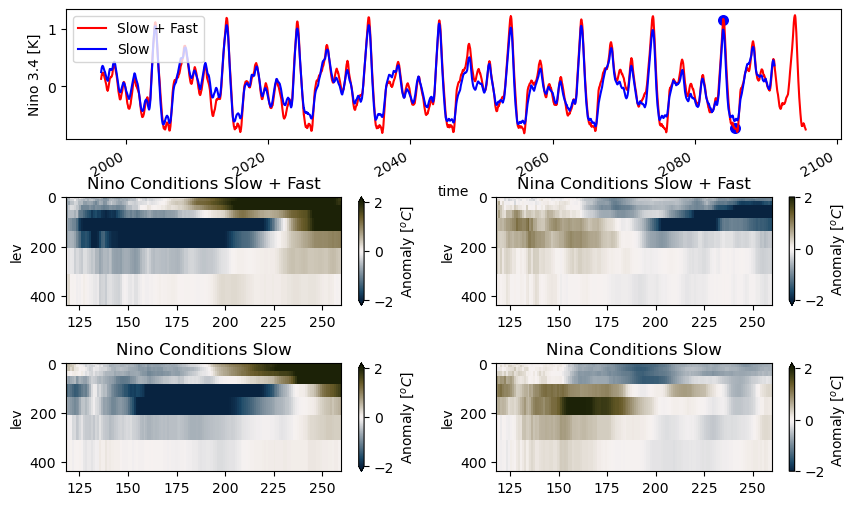

In [17]:

fig,axs = plt.subplot_mosaic([['time series','time series'],['nino_true','nina_true'],['nino_pred','nina_pred']],figsize = (10,6),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.6,.5,.5], 'wspace': 0.25,'hspace':.5})
nino_pred_compute_clim.plot(label = 'Slow + Fast', c = 'r',ax = axs['time series'])
nino_pred_compute_clim_temp.plot(label = 'Slow', c = 'b',ax = axs['time series'])

nino_pred_compute_clim.isel(time = slice(day_max-30,day_max-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'b',ax = axs['time series'])
nino_pred_compute_clim.isel(time = slice(day_min-30,day_min-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'b',ax = axs['time series'])

axs['time series'].set_title('')
axs['time series'].legend()
# axs['time series'].set_title('Nino 3.4 Index')

day_start = day_max
window = 3

time_slice = slice(ds_prediction_temp['time'][day_start],ds_prediction_temp['time'][day_start+window])
times = ds_prediction_temp['time'][day_start:day_start+window].data
days_of_year = [Timestamp(i).dayofyear for i in times]
true_clim_to_remove = clim_pred_temp.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
true_clim_to_remove['time'] = times
pred_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times

tropics_profile = (ds_prediction_all['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5),lev = slice(0,500),)-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (ds_prediction_temp['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile = tropics_profile.rename('Anomaly')
tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
tropics_profile = tropics_profile.assign_attrs(units = r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r"${^oC}$")

tropics_profile.plot.pcolormesh(ax = axs['nino_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nino_true'].set_title('Nino Conditions Slow + Fast')
axs['nino_true'].set_xlabel('')
axs['nino_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nino_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nino_pred'].set_title('Nino Conditions Slow')
axs['nino_pred'].set_xlabel('')
axs['nino_pred'].invert_yaxis()


axs['time series'].legend()

day_start = day_min
window = 3

time_slice = slice(ds_prediction_temp['time'][day_start],ds_prediction_temp['time'][day_start+window])
times = ds_prediction_temp['time'][day_start:day_start+window].data
days_of_year = [Timestamp(i).dayofyear for i in times]
pred_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times
true_clim_to_remove = clim_pred_temp.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
true_clim_to_remove['time'] = times

tropics_profile = (ds_prediction_all['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5),lev = slice(0,500),)-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (ds_prediction_temp['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile = tropics_profile.rename('Anomaly')
tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
tropics_profile = tropics_profile.assign_attrs(units = r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r"${^oC}$")

tropics_profile.plot.pcolormesh(ax = axs['nina_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nina_true'].set_title('Nina Conditions Slow + Fast')
axs['nina_true'].set_xlabel('')
axs['nina_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nina_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nina_pred'].set_title('Nina Conditions Slow')
axs['nina_pred'].set_xlabel('')
axs['nina_pred'].invert_yaxis()

plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Nino_Figure_Long"+suffix+".png", bbox_inches='tight')
